In [127]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base
from Kea.utils import funcs

from scipy import fft

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 2
N = 256
#L = 1.
#L = N
L = 5.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

alphas = [-(D+1.)]
breaks = [1.]

twopi = 2.*np.pi
dk = twopi/L

In [128]:
# i = 0,...,N/2
# j = 0,...,N/2
# A[i][j] = conjugate(A[i0][j0])
# A[N/2][0].imag = 0
# A[0][N/2].imag = 0
# A[N/2][N/2].imag = 0
# i = 1,...,N/2-1
# j = 1,...,N/2-1
# A[i][N-j] = conjugate(A[N-i][j])
# # Top left corner-bottom right corner
# # Negative (slope) diagonal
# for i in range(1,grid_dims[0]//2):
#     for j in range(1,grid_dims[1]//2):
#         # Top left corner = complex conjugate of bottom right
#         output[grid_dims[0]-i,j] = np.conjugate(output[i,grid_dims[1]-j])
# Top right corner-bottom left corner
# Positive (slope) diagonal
# Includes the nyquist terms
# for i in range(0, grid_dims[0]//2+1):
#    for j in range(0, grid_dims[1]//2+1):
#        if i == 0:
#            i0 = 0
#        else:
#            i0 = grid_dims[0]-i
#        if j == 0:
#            j0 = 0
#        else:
#            j0 = grid_dims[1]-j
#         # top right corner = complex conjugate of bottom left
#        output[i0][j0] = np.conjugate(output[i][j])
#r_idx = tuple([slice(1, n//2) for n in grid_dims])
#l_idx = tuple([slice(n, n//2, -1) for n in grid_dims])
#output[l_idx] = np.conjugate(output[r_idx])

In [138]:
import itertools

def create_fbm(grid_dims, phys_dims, alphas, breaks, gfunc='smooth_pow', func_kwargs={}):
    assert len(set(grid_dims)) <= 1, 'Must have the same number of points in each dimension'
    if phys_dims is None:
        phys_dims = [2. * np.pi for _ in phys_dims]
    assert len(set(phys_dims)) <= 1, 'Must be the same length in each dimension'

    dx = [phys_dims[i]/grid_dims[i] for i in range(len(grid_dims))]
    dxD = np.prod(dx)
    dk = [1./phys_dims[i] for i in range(len(phys_dims))]
    dkD = np.prod(dk)

    # Generate wavenumbers
    kvec = [np.fft.fftfreq(grid_dims[i])*2.*np.pi/dx[i] for i in range(len(grid_dims))]
    kgrid = np.meshgrid(*kvec, indexing='ij')
    kk = np.linalg.norm(kgrid, axis=0)

    if isinstance(gfunc, str):
        gfunc = getattr(funcs, gfunc)

    # Generate fBM in Fourier space
    output = gfunc(kk, alphas, breaks, **func_kwargs).astype('complex')
    #C = 2. / dkD
    C = 
    output = np.sqrt(output * C)

    # Random phases
    phases = np.random.uniform(0, 2.*np.pi, size=grid_dims)
    #phases = phases - fft.fftshift(phases)
    phases = np.cos(phases) + 1j * np.sin(phases)
    #phases /= np.sqrt(np.sum(phases**2) / float(phases.size))
    output = output * phases
    #output = output

    ## Ensure the function is Hermitian
    # => The FT is real-valued
    # DC value
    zero_idx = tuple([0 for _ in grid_dims])
    output[zero_idx] = 0. + 1j * 0.

    # The nyquist components without a partner must be their own real
    args = [[n//2, 0] for n in grid_dims]
    idx = list(itertools.product(*args))
    for i in range(len(idx)):
        output[tuple(idx[i])] = output[tuple(idx[i])].real + 1j * 0.

    # l_args = [[slice(1, n//2 + 1), 0] for n in grid_dims]
    # l_idx = list(itertools.product(*l_args))
    # r_args = [[slice(n, n//2 - 1, -1), 0] for n in grid_dims]
    # r_idx = list(itertools.product(*r_args))
    # for i in range(len(l_idx)):
    #     output[tuple(l_idx[i])] = np.conjugate(output[tuple(r_idx[i])])

    # NOTE: There is redundant computation here
    # l_args = [[slice(1, n//2 + 1), slice(n, n//2 - 1, -1), 0, n//2] for n in grid_dims]
    # l_idx = list(itertools.product(*l_args))
    # r_args = [[slice(n, n//2 - 1, -1), slice(1, n//2 + 1), 0, n//2] for n in grid_dims]
    # r_idx = list(itertools.product(*r_args))
    # for i in range(len(l_idx)):
    #     output[tuple(l_idx[i])] = np.conjugate(output[tuple(r_idx[i])])

    # if len(grid_dims) == 2:
    #     for i in range(0, N//2+1):
    #         for j in range(0, N//2+1):
    #             i0 = 0 if i == 0 else N-i
    #             j0 = 0 if j == 0 else N-j
    #             output[i,j] = np.conjugate(output[i0,j0])
    #             output[i0,j] = np.conjugate(output[i,j0])

    # if len(grid_dims) == 3:
    #     for i in range(0, N//2+1):
    #         for j in range(0, N//2+1):
    #             for k in range(0, N//2+1):
    #                 i0 = 0 if i == 0 else N-i
    #                 j0 = 0 if j == 0 else N-j
    #                 k0 = 0 if k == 0 else N-k
    #                 output[i,j,k] = np.conjugate(output[i0,j0,k0])
    #                 output[i0,j,k] = np.conjugate(output[i,j0,k0])
    #                 output[i,j0,k] = np.conjugate(output[i0,j,k0])
    #                 output[i,j,k0] = np.conjugate(output[i0,j0,k])

    return dkD * output

In [139]:
def verify_2d(grid_dims, phys_dims, alphas, breaks):
    output = create_fbm(grid_dims, phys_dims, alphas, breaks)
    for i in range(0, grid_dims[0]//2+1):
        for j in range(0, grid_dims[1]//2+1):
            if i == 0:
                i0 = 0
            else:
                i0 = grid_dims[0]-i
            if j == 0:
                j0 = 0
            else:
                j0 = grid_dims[1]-j
            assert np.isclose(output[i0][j0].imag, -output[i][j].imag), '1_%s:%s-%s:%s' % (i,j,i0,j0)
            assert np.isclose(output[i0][j].imag, -output[i][j0].imag), '2_%s:%s-%s:%s' % (i0,j,i,j0)
            assert np.isclose(output[i][j0].imag, -output[i0][j].imag), '3_%s:%s-%s:%s' % (i,j0,i0,j)
    #for i in range(1,grid_dims[0]//2):
    #    for j in range(1,grid_dims[1]//2):
    #        assert np.isclose(output[grid_dims[0]-i,j].imag, -output[i,grid_dims[1]-j].imag), '2_%s:%s-%s:%s' % (N-i,j,i,N-j)

In [140]:
verify_2d(grid_dims, phys_dims, alphas, breaks)

AssertionError: 1_0:1-0:255

In [ ]:
fbm = create_fbm(grid_dims, phys_dims, alphas, breaks)#, 'smooth')
fbm = fft.fftshift(fbm)

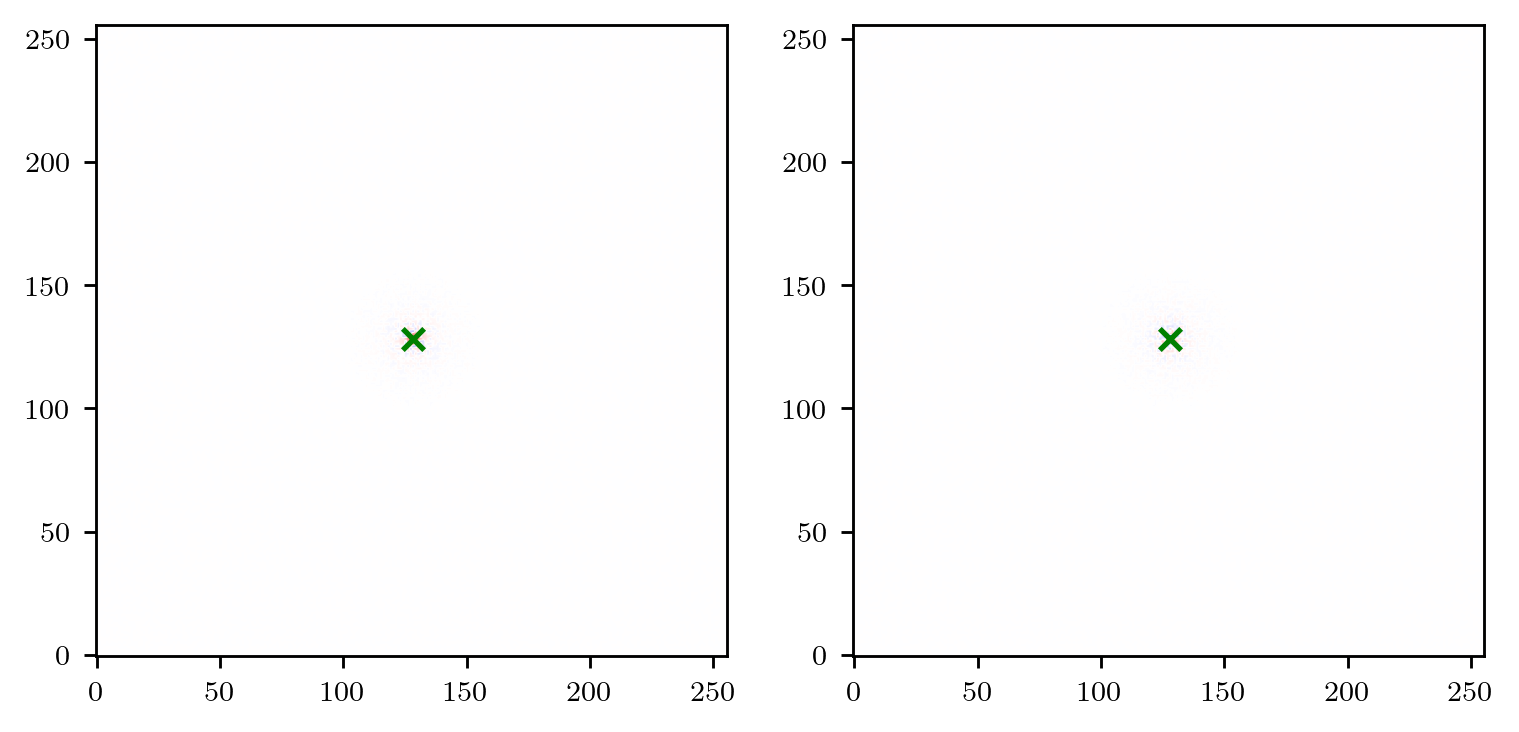

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(7., 3.5), dpi=256)

cmin = np.nanmin([np.nanmin(fbm.real), np.nanmin(fbm.imag)])
cmax = np.nanmax([np.nanmax(fbm.real), np.nanmax(fbm.imag)])

ax[0].imshow(fbm.real, origin='lower', cmap='bwr', vmin=cmin, vmax=cmax)
ax[1].imshow(fbm.imag, origin='lower', cmap='bwr', vmin=cmin, vmax=cmax)
ax[0].scatter(N//2, N//2, marker='x', color='green')
ax[1].scatter(N//2, N//2, marker='x', color='green')

/tmp/ipykernel_19869/1411104624.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(E), origin='lower')


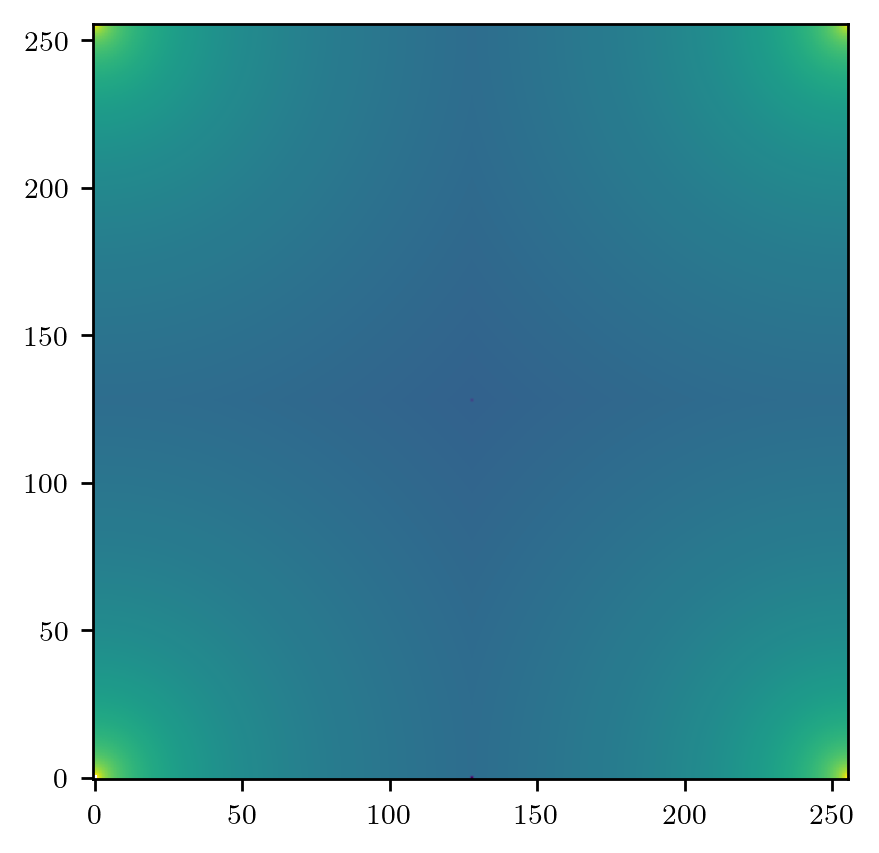

In [ ]:
E = np.abs(np.fft.ifftshift(fbm))**2

plt.imshow(np.log10(E), origin='lower')
#plt.scatter(grid_dims[0]//2, grid_dims[1]//2, marker='x', color='red')

/tmp/ipykernel_19869/164136289.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(E), origin='lower')


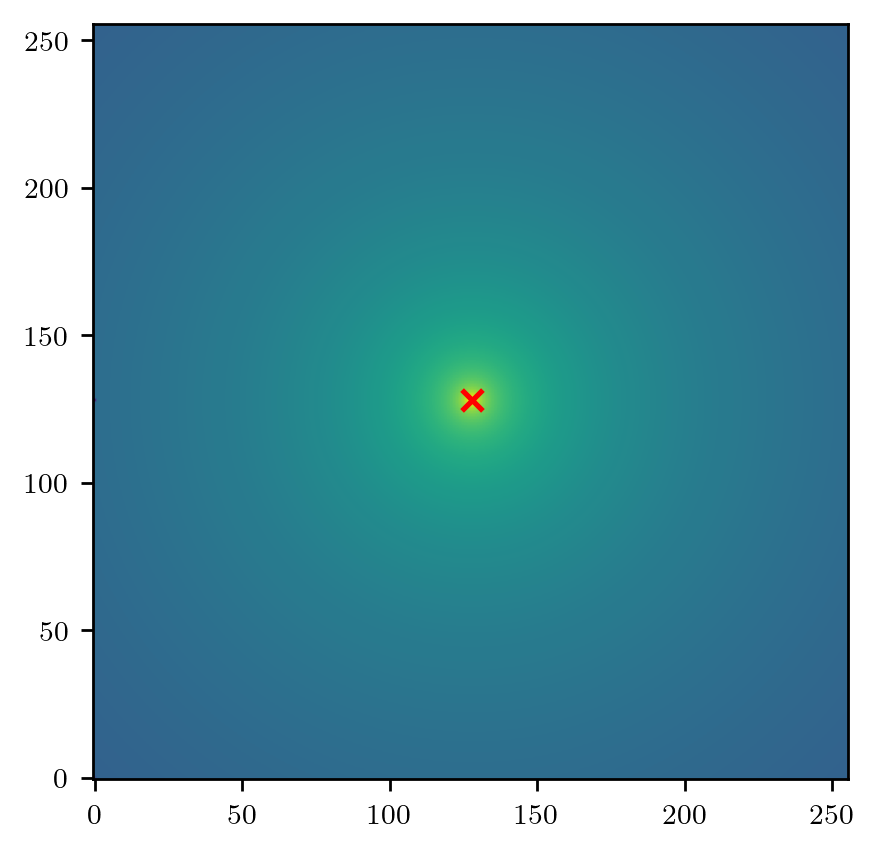

In [ ]:
E = np.abs(fbm)**2

plt.imshow(np.log10(E), origin='lower')
plt.scatter(grid_dims[0]//2, grid_dims[1]//2, marker='x', color='red')

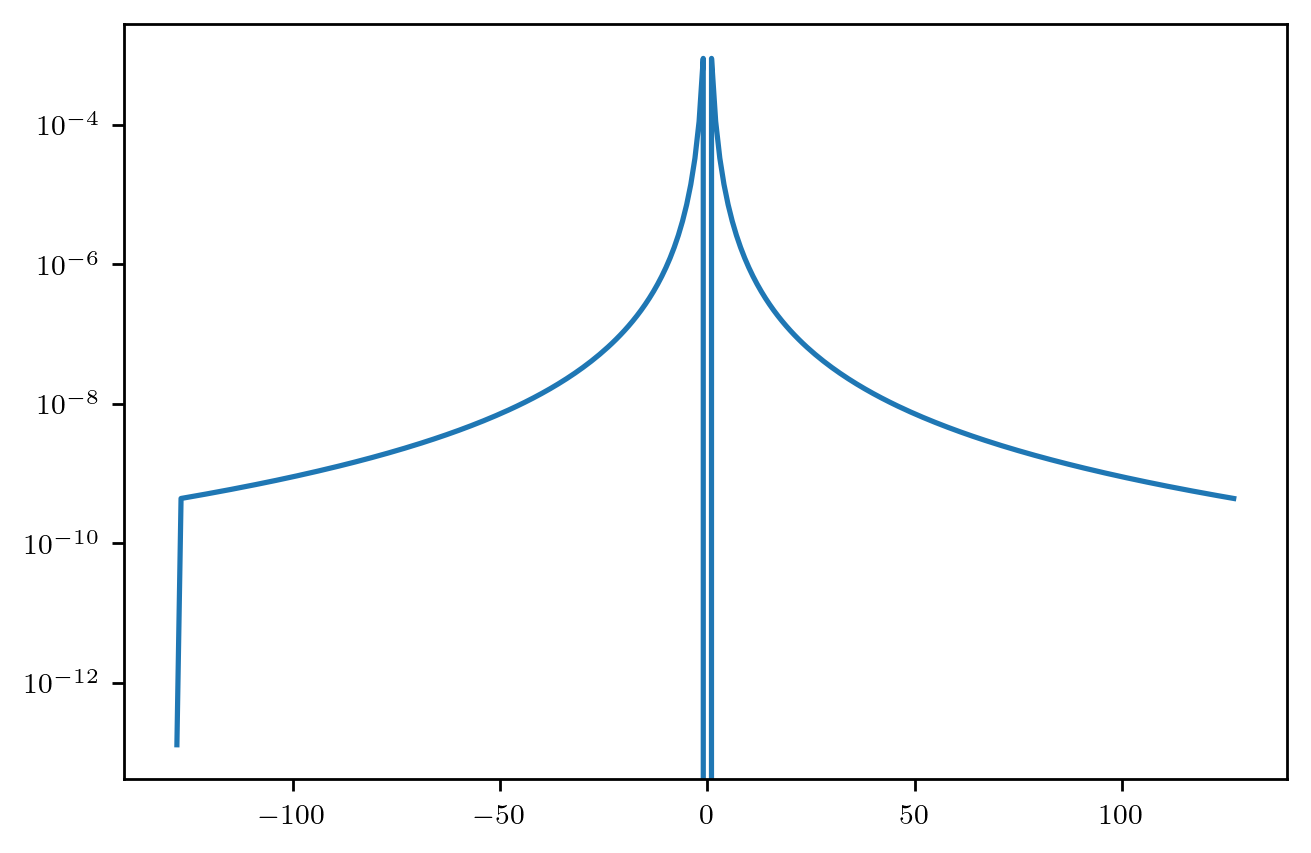

In [ ]:
plt.plot(np.arange(-N//2, N//2), E[N//2,:])
plt.yscale('log')

In [ ]:

def create_fbm2(grid_dims, phys_dims, alphas, breaks, gfunc='smooth_pow', func_kwargs={}):
    output = create_fbm(grid_dims, phys_dims, alphas, breaks, gfunc)
    print(np.nansum(np.abs(output)**2))
    fbm = fft.ifftn(output, norm='forward')
    return fbm


0.008048393569667979
0.025202690679347554
-0.2723491843846618 0.3041264317329083


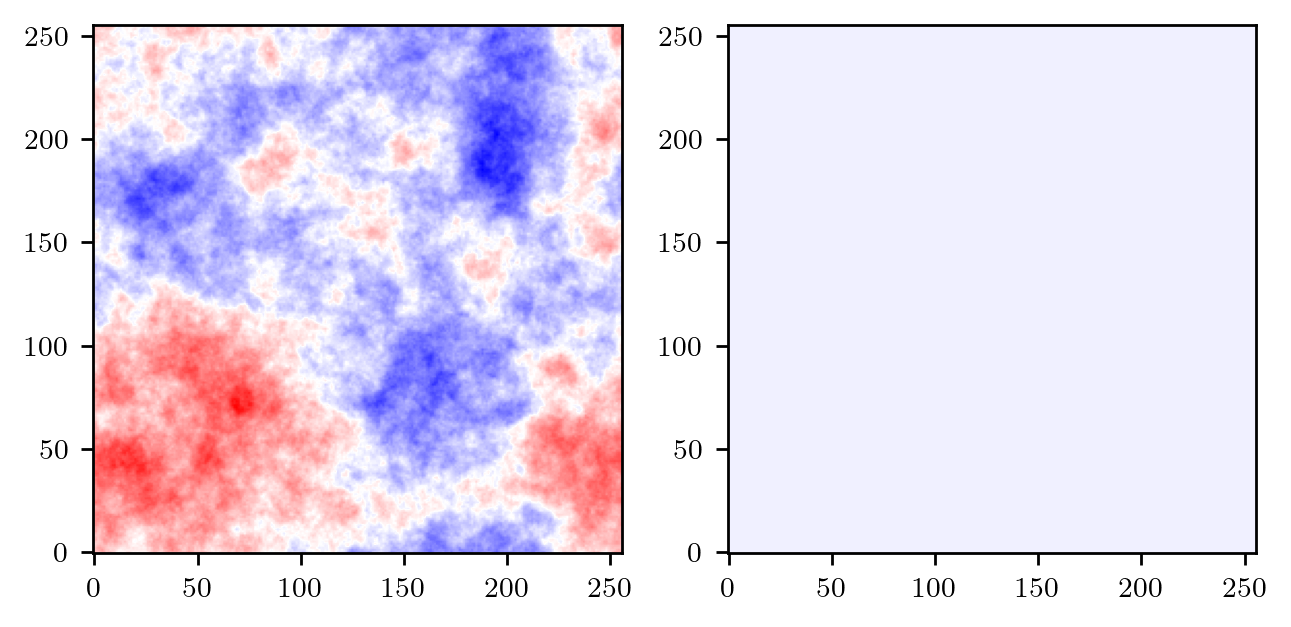

In [ ]:
fbm2 = create_fbm2(grid_dims, phys_dims, alphas, breaks)

print(np.max(fbm.imag))

fig, ax = plt.subplots(1, 2)

cmin = np.nanmin([np.nanmin(fbm2.real), np.nanmin(fbm2.imag)])
cmax = np.nanmax([np.nanmax(fbm2.real), np.nanmax(fbm2.imag)])

ax[0].imshow(fbm2.real, cmap='bwr', origin='lower', vmin=cmin, vmax=cmax)
ax[1].imshow(fbm2.imag, cmap='bwr', origin='lower', vmin=cmin, vmax=cmax)
print(cmin, cmax)

0.00804839356966798


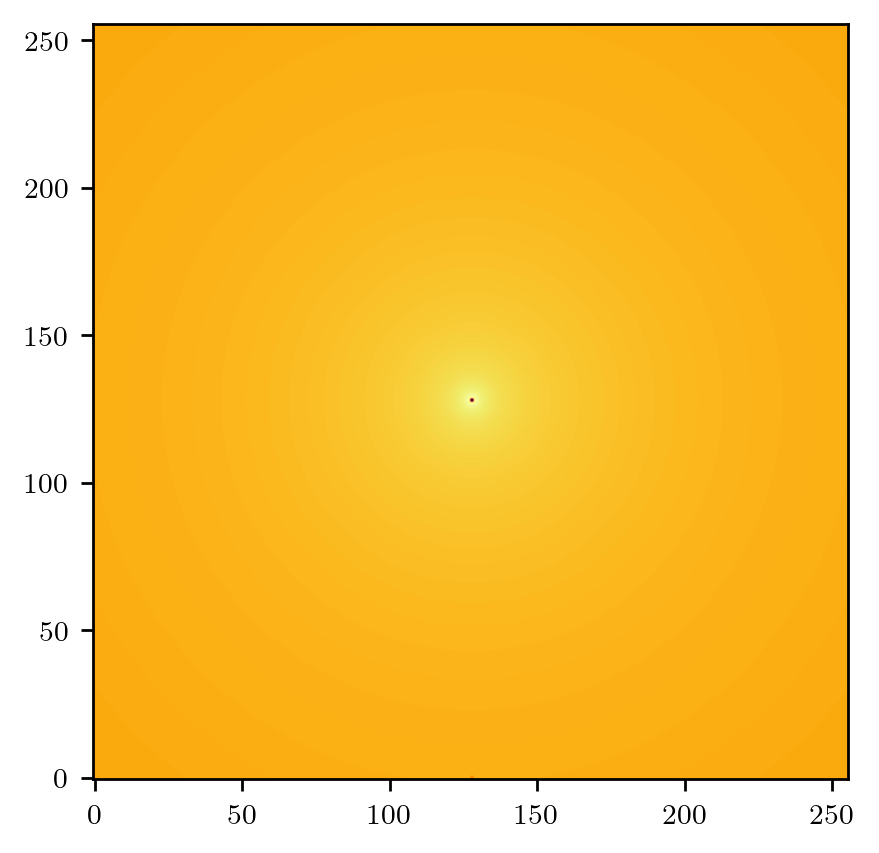

In [ ]:
#k, fek, _ = spectra_base.calculate_integrated_spectrum((fbm.real,), lenn=phys_dims, method='periodogram', spec_type='modal')
fek = fft.fftn(fbm2.real, norm='forward')
fek = fft.fftshift(fek)
fek = np.abs(fek)**2
print(np.nansum(fek))
plt.imshow(np.log10(fek), origin='lower', cmap='inferno')

1.6256583219441067e-34


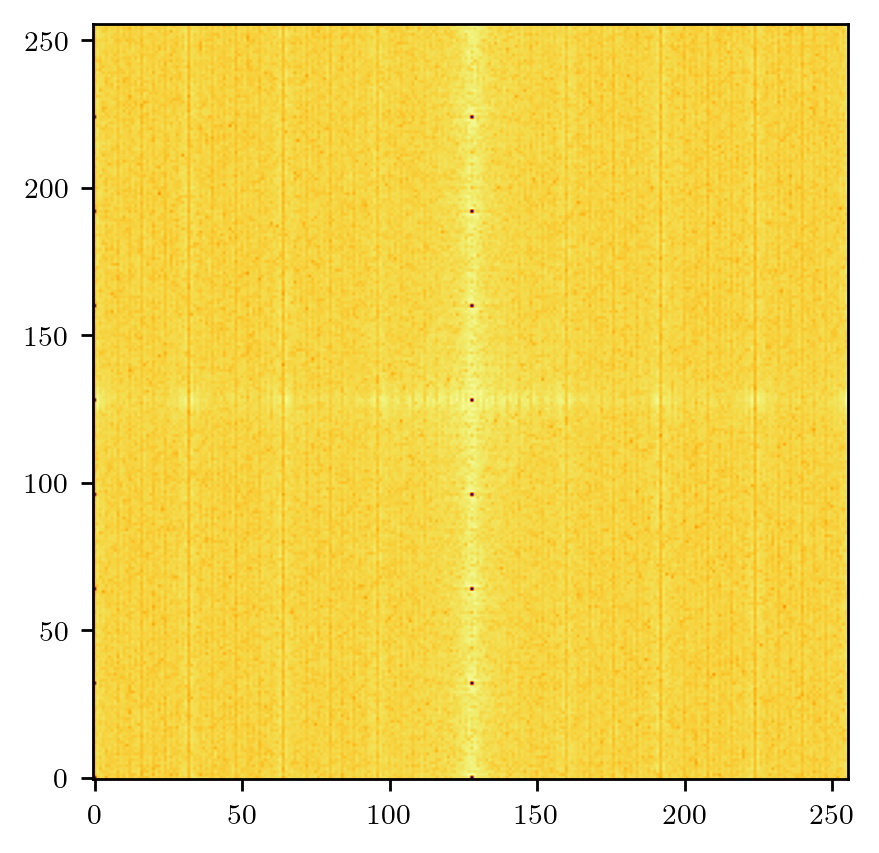

In [ ]:
fekim = fft.fftn(fbm2.imag, norm='forward')
fekim = fft.fftshift(fekim)
fekim = np.abs(fekim)**2
print(np.nansum(fekim))
plt.imshow(np.log10(fekim), origin='lower', cmap='inferno')

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[]

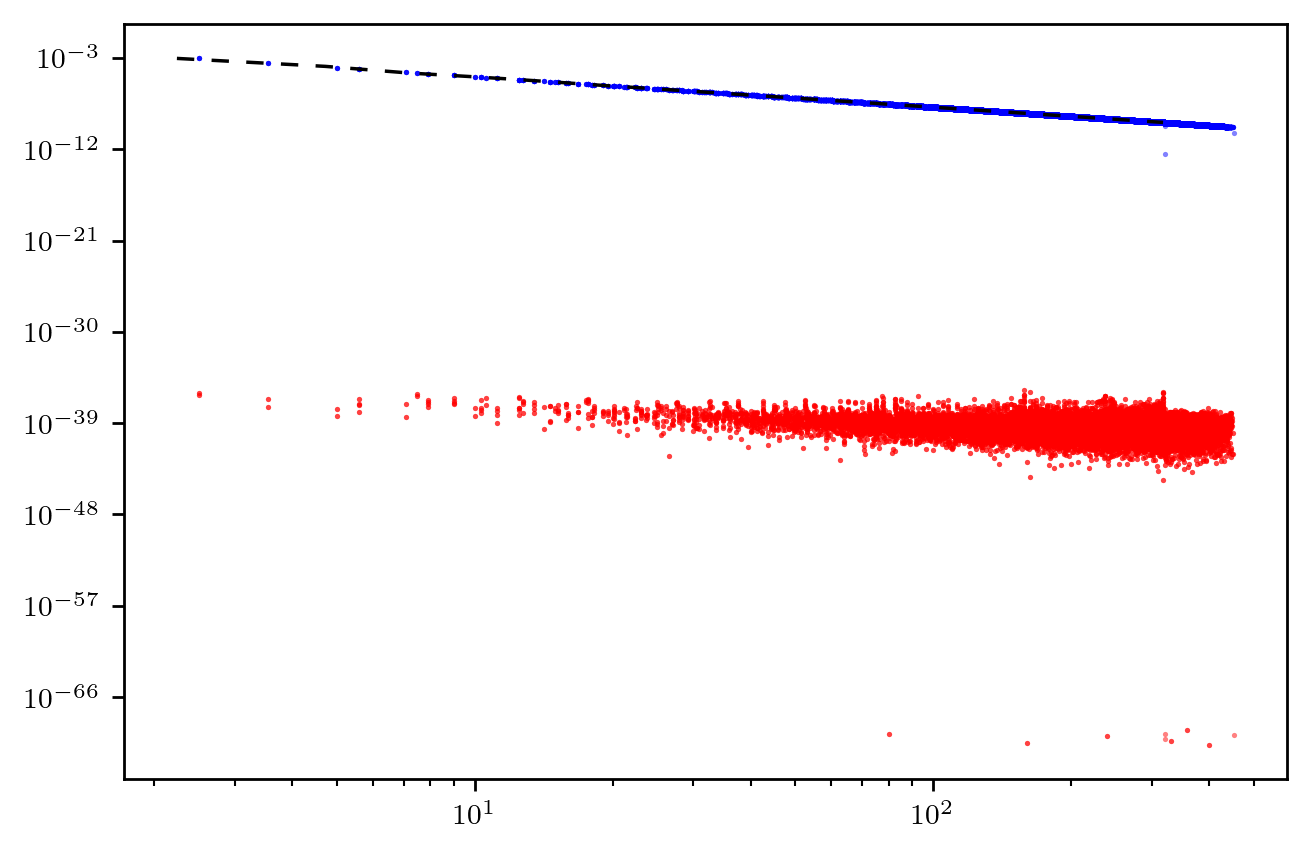

In [ ]:
kvec = []

for i in grid_dims:
    kvec.append(fft.fftshift(fft.fftfreq(N))*2.*np.pi*N/L)

km, fekm, _ = spectra_base.spectrum_integrate(
    kvec, fek, spec_type='modal', lenn=phys_dims,
    min_bin=1.)

kmesh = spectra_base.wavenumber_mesh(kvec, phys_dims)
plt.scatter(kmesh, fek, marker='.', s=1., alpha=0.5, color='blue')

plt.scatter(kmesh, fekim, marker='.', s=1., alpha=0.5, color='red')

plt.plot(km, fekm, linestyle=(0,(5,5)), color='black', linewidth=1.)
plt.loglog()
#plt.ylim((np.nanmax(fek)/10**5,np.nanmax(fek)))

In [ ]:
D = 3
N = 256
#L = 1.
#L = N
L = 5.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

alphas = [-(D+1.)]
breaks = [1.]

twopi = 2.*np.pi
dk = twopi/L
fbm3 = create_fbm2(grid_dims, phys_dims, alphas, breaks)

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:74: RuntimeWarning: divide by zero encountered in power
  terms.append((xx/bb[0])**(-a[0]))


0.0005152227798064538


In [ ]:
def verify_3d(grid_dims, phys_dims, alphas, breaks):
    output = create_fbm(grid_dims, phys_dims, alphas, breaks)
    for i in range(0, grid_dims[0]//2+1):
        for j in range(0, grid_dims[1]//2+1):
            for k in range(0, grid_dims[2]//2+1):
                if i == 0:
                    i0 = 0
                else:
                    i0 = grid_dims[0]-i
                if j == 0:
                    j0 = 0
                else:
                    j0 = grid_dims[1]-j
                if k == 0:
                    k0 = 0
                else:
                    k0 = grid_dims[2]-k

                assert np.isclose(output[i0][j0][k0].imag, -output[i][j][k].imag), '1_%s:%s:%s-%s:%s:%s' % (i,j,k,i0,j0,k0)

                assert np.isclose(output[i][j0][k0].imag, -output[i0][j][k].imag), '2_%s:%s:%s-%s:%s:%s' % (i,j0,k0,i0,j,k)
                assert np.isclose(output[i0][j][k0].imag, -output[i][j0][k].imag), '3_%s:%s:%s-%s:%s:%s' % (i0,j,k0,i,j0,k)
                assert np.isclose(output[i0][j0][k].imag, -output[i][j][k0].imag), '4_%s:%s:%s-%s:%s:%s' % (i0,j0,k,i,j,k0)

    #for i in range(1,grid_dims[0]//2):
    #    for j in range(1,grid_dims[1]//2):
    #        for k in range(1,grid_dims[2]//2):
    #            assert np.isclose(output[grid_dims[0]-i,j,k].imag, -output[i,grid_dims[1]-j,grid_dims[2]-k].imag), '2_%s:%s:%s-%s:%s:%s' % (N-i,j,k,i,N-j,N-k)
    #            assert np.isclose(output[i,grid_dims[1]-j,k].imag, -output[grid_dims[0]-i,j,grid_dims[2]-k].imag), '2_%s:%s:%s-%s:%s:%s' % (i,N-j,k,N-i,j,N-k)
    #            assert np.isclose(output[i,j,grid_dims[2]-k].imag, -output[grid_dims[0]-i,grid_dims[1]-j,k].imag), '2_%s:%s:%s-%s:%s:%s' % (i,j,N-k,N-i,N-j,k)

In [ ]:
verify_3d(grid_dims, phys_dims, alphas, breaks)

0.0005152227798064553
1.399351807619863e-35


[]

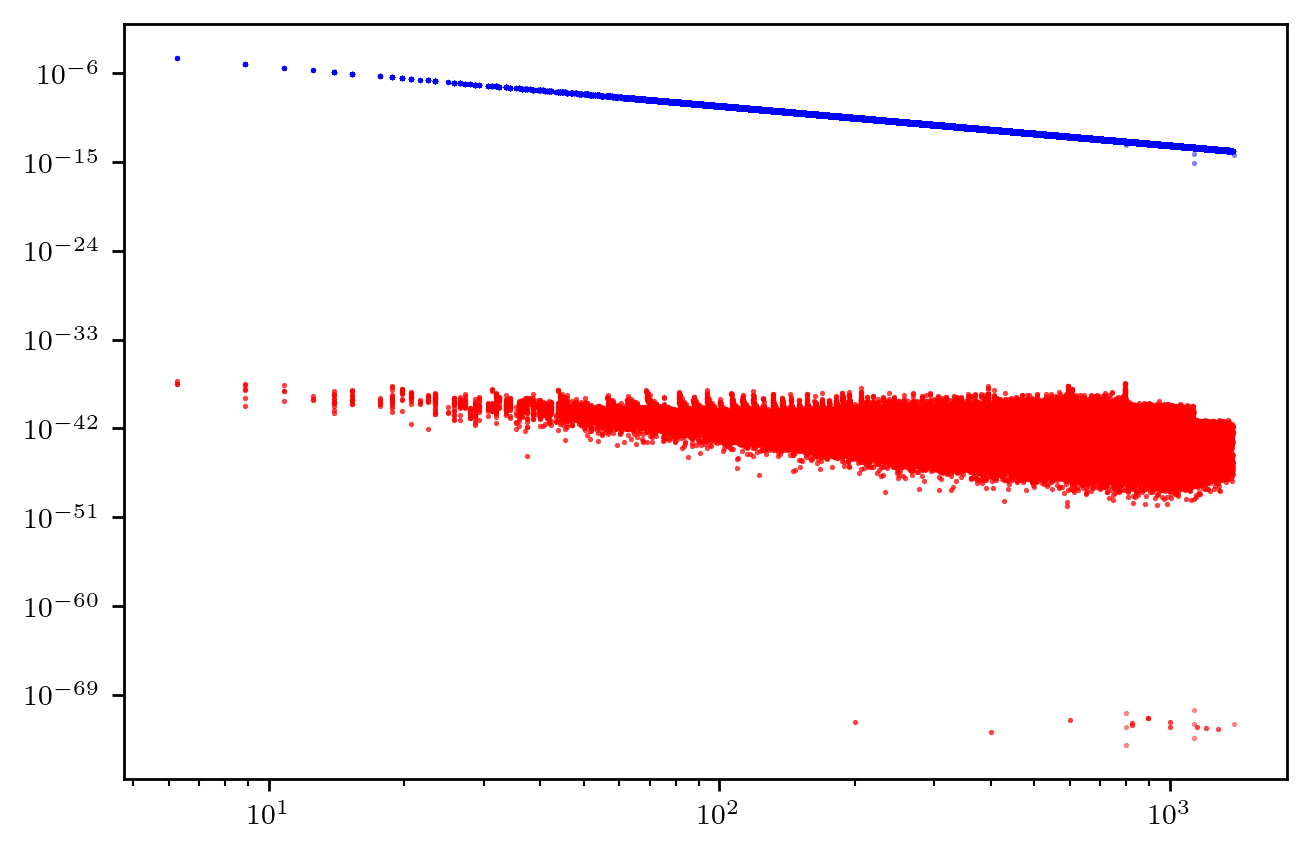

In [ ]:
kvec = []

for i in grid_dims:
    kvec.append(fft.fftshift(fft.fftfreq(N))*2.*np.pi*N/L)
kmesh = spectra_base.wavenumber_mesh(kvec, phys_dims)

fek = fft.fftn(fbm3.real, norm='forward')
fek = fft.fftshift(fek)
fek = np.abs(fek)**2
print(np.nansum(fek))

fekim = fft.fftn(fbm3.imag, norm='forward')
fekim = fft.fftshift(fekim)
fekim = np.abs(fekim)**2
print(np.nansum(fekim))

plt.scatter(kmesh, fek, marker='.', s=1., alpha=0.5, color='blue')
plt.scatter(kmesh, fekim, marker='.', s=1., alpha=0.5, color='red')
plt.loglog()


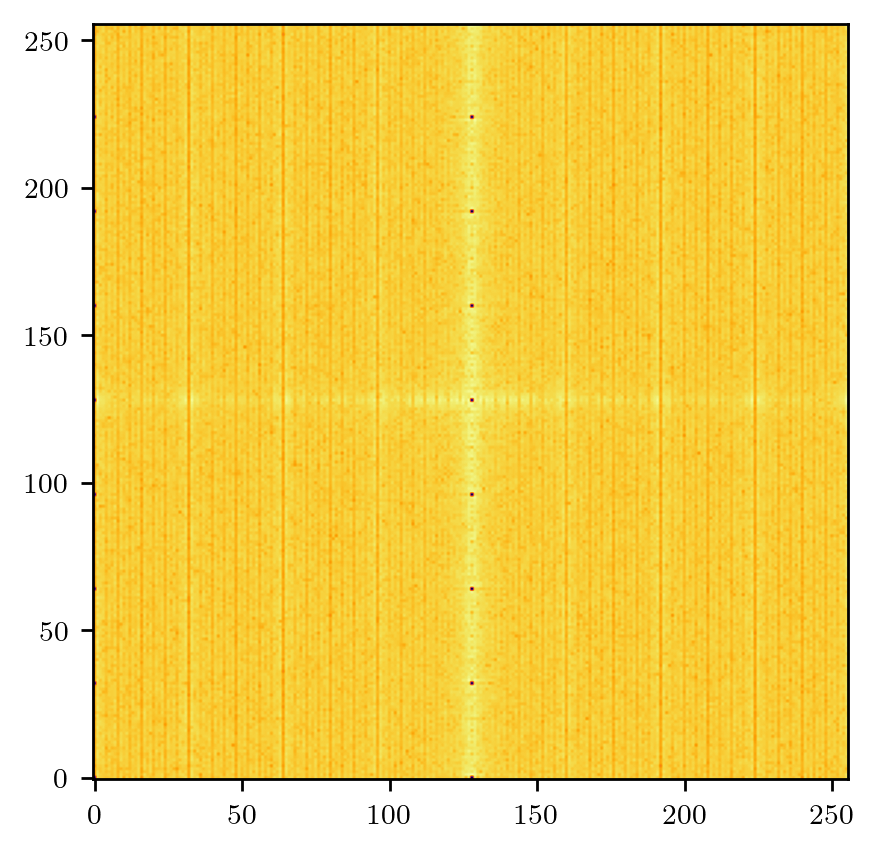

In [ ]:
plt.imshow(np.log10(fekim[:,:,N//2]), origin='lower', cmap='inferno')

In [ ]:
# import itertools

# def create_fbm3(grid_dims, phys_dims, alphas, breaks, gfunc='smooth_pow', func_kwargs={}):
#     assert len(set(grid_dims)) <= 1, 'Must have the same number of points in each dimension'
#     if phys_dims is None:
#         phys_dims = [2. * np.pi for _ in phys_dims]
#     assert len(set(phys_dims)) <= 1, 'Must be the same length in each dimension'

#     dx = [phys_dims[i]/grid_dims[i] for i in range(len(grid_dims))]
#     dxD = np.prod(dx)
#     dk = [1./phys_dims[i] for i in range(len(phys_dims))]
#     dkD = np.prod(dk)

#     # Generate wavenumbers
#     kvec = [np.fft.fftfreq(grid_dims[i])*2.*np.pi/dx[i] for i in range(len(grid_dims))]
#     kgrid = np.meshgrid(*kvec, indexing='ij')
#     kk = np.linalg.norm(kgrid, axis=0)

#     if isinstance(gfunc, str):
#         gfunc = getattr(funcs, gfunc)

#     # Generate fBM in Fourier space
#     output = gfunc(kk, alphas, breaks, **func_kwargs).astype('complex')
#     C = 2./dkD
#     output = np.sqrt(output * C)
#     # Random phases
#     phases = np.random.uniform(0, 2.*np.pi, size=grid_dims)
#     phases = np.cos(phases) + 1j * np.sin(phases)
#     #phases /= np.sqrt(np.sum(phases**2) / float(phases.size))
#     output = output * phases
#     #output = output

#     ## Ensure the function is Hermitian
#     # => The FT is real-valued
#     # DC value
#     czero = 0. + 1j * 0.
#     cone = 1. + 1j * 1.
#     c500 = 5000. + 1j * 5000.

#     zero_idx = tuple([0 for _ in grid_dims])
#     output[zero_idx] = 0. + 1j * 0.

#     # The nyquist components without a partner must be their own real
#     args = [[n//2, 0] for n in grid_dims]
#     idx = list(itertools.product(*args))
#     for i in range(len(idx)):
#         output[tuple(idx[i])] = output[tuple(idx[i])].real + 1j * 0.
#         #output[tuple(idx[i])] = c500

#     l_args = [[slice(1, n//2 + 1), 0, n//2] for n in grid_dims]
#     l_idx = list(itertools.product(*l_args))
#     r_args = [[slice(n, n//2 - 1, -1), 0, n//2] for n in grid_dims]
#     r_idx = list(itertools.product(*r_args))
#     for i in range(len(l_idx)):
#         output[tuple(l_idx[i])] = np.conjugate(output[tuple(r_idx[i])])
#         #output[tuple(l_idx[i])] = c500
#         #output[tuple(r_idx[i])] = c500

#     ## NOTE: There is redundant computation here
#     l_args = [[slice(1, n//2), slice(n, n//2, -1), 0, n//2] for n in grid_dims]
#     l_idx = list(itertools.product(*l_args))
#     r_args = [[slice(n, n//2, -1), slice(1, n//2), 0, n//2] for n in grid_dims]
#     r_idx = list(itertools.product(*r_args))
#     for i in range(len(l_idx)):
#         output[tuple(l_idx[i])] = np.conjugate(output[tuple(r_idx[i])])
#         #output[tuple(r_idx[i])] = c500
#         #output[tuple(l_idx[i])] = c500

#     #output[zero_idx] = c500#0. + 1j * 0.

#     return output#dkD * output

In [ ]:
# fbm = create_fbm3(grid_dims, phys_dims, alphas, breaks)
# #fbm = fft.fftshift(fbm)

In [ ]:

# idx = [slice(0, n) for n in grid_dims]
# idx[2] = N-1
# idx = tuple(idx)

# fig, ax = plt.subplots(1, 2, figsize=(7., 3.5), dpi=256)

# cmin = np.nanmin([np.nanmin(fbm.real), np.nanmin(fbm.imag)])
# cmax = np.nanmax([np.nanmax(fbm.real), np.nanmax(fbm.imag)])

# ax[0].imshow(fbm.real[idx], origin='lower', cmap='inferno', vmin=cmin, vmax=cmax)
# ax[1].imshow(fbm.imag[idx], origin='lower', cmap='inferno', vmin=cmin, vmax=cmax)
# #ax[0].scatter(N//2, N//2, marker='x', color='green')
# #ax[1].scatter(N//2, N//2, marker='x', color='green')


In [ ]:
# fbm = fft.ifftshift(fbm)
# E = np.abs